1. In pandas.pivot_table, setting margins=True adds "All" rows and columns to your output table, which display the grand totals or overall averages for your data.
- df.pivot_table(
-            index = ['sex', 'smoker'],
-            columns = ['day', 'time'],
-            aggfunc = {
-                      'size': 'mean',
-                      'tip': 'max',
-                      'total_bill' : 'sum'
-               } ,
-           margins = True )['size']

1. You use fill_value because pivoting data often creates blank intersections where no matching data points exist. By default, pandas leaves these blanks as NaN (Not a Number), which messes up calculations and looks untidy.fill_value lets you replace those blanks with a clean fallback number (usually 0).

In [27]:
import numpy as np 
import pandas as pd 
import seaborn as sns 

In [28]:
df = sns.load_dataset('tips')

In [29]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [30]:
df.pivot_table(index='sex', columns='smoker', values='total_bill',aggfunc = 'std')


smoker,Yes,No
sex,,
Male,9.911845,8.726566
Female,9.189751,7.286455


In [31]:
df.pivot_table(index='sex', columns='smoker', values='total_bill').size


4

In [32]:
# MULTI DIMENSIONAL PIOT TABLE :
df.pivot_table(index = ['sex', 'smoker'],
               columns = ['day', 'time'],
               aggfunc = {
                      'size': 'mean',
                      'tip': 'max',
                      'total_bill' : 'sum'
               } ,margins = True )


size                                                 \
day                Thur              Fri                 Sat       Sun   
time              Lunch Dinner     Lunch    Dinner    Dinner    Dinner   
sex    smoker                                                            
Male   Yes     2.300000    NaN  1.666667  2.400000  2.629630  2.600000   
       No      2.500000    NaN       NaN  2.000000  2.656250  2.883721   
Female Yes     2.428571    NaN  2.000000  2.000000  2.200000  2.500000   
       No      2.500000    2.0  3.000000  2.000000  2.307692  3.071429   
All            2.459016    2.0  2.000000  2.166667  2.517241  2.842105   

                          tip               ...                      \
day                 All  Thur          Fri  ...    Sat    Sun   All   
time                    Lunch Dinner Lunch  ... Dinner Dinner         
sex    smoker                               ...                       
Male   Yes     2.500000  5.00    NaN  2.20  ...  10.00    6.5  10.0   
       No      2.711340  6.70    NaN   NaN  ...   9.00    6.0   9.0   
Female Yes     2.242424  5.00    NaN  3.48  ...   6.50    4.0   6.5   
       No      2.592593  5.17    3.0  3.00  ...   4.67    5.2   5.2   
All            2.569672  6.70    3.0  3.48  ...  10.00    6.5  10.0   

              total_bill                                                   
day                 Thur           Fri              Sat      Sun      All  
time               Lunch Dinner  Lunch  Dinner   Dinner   Dinner           
sex    smoker                                                              
Male   Yes        191.71    NaN  34.16  129.46   589.62   392.12  1337.07  
       No         369.73    NaN    NaN   34.95   637.73   877.34  1919.75  
Female Yes        134.53    NaN  39.78   48.80   304.00    66.16   593.27  
       No         381.58  18.78  15.98   22.75   247.05   291.54   977.68  
All              1077.55  18.78  89.92  235.96  1778.40  1627.16  4827.77  

[5 rows x 21 columns]

In [33]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [39]:
# Ploting the Graph :
df1 = pd.read_csv(r"C:\Users\HOME\Downloads\expense_data.csv")

In [40]:
df1['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [44]:
df1['Date'] = pd.to_datetime(df['Date'])


In [45]:
df1.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='str')

In [55]:
df1['Month'] = df1['Date'].dt.month_name()

<Axes: xlabel='Month'>

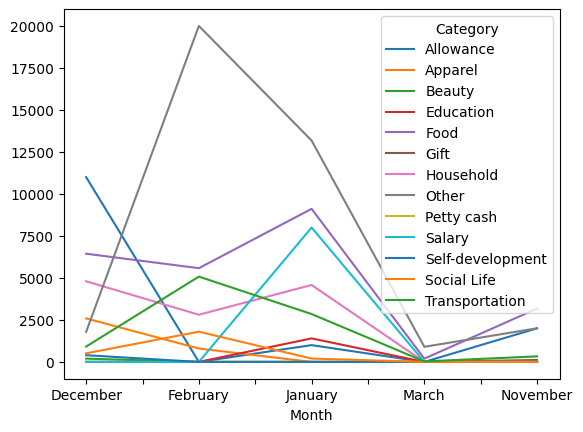

In [58]:
df1.pivot_table(index = 'Month', columns = 'Category',values ='INR',aggfunc = 'sum', fill_value = 0  ).plot()